# MA-SpecFormer — JDA Reconstruction Benchmark

Evaluates reconstruction quality on JDA PRISM/F100LP validation spectra (~56 pixels, 1–2 µm).

**Sections**
1. **Token Reconstruction** — per-token decoder head, no masking  
   - 1.1 Spectrum gallery (adaptive N, normalized)  
   - 1.2 Statistics: normalized space  
   - 1.3 Statistics: physical space (uJy)  
2. **CLS Reconstruction** — global spectrum decoded from CLS embedding  
   - 2.1 Spectrum gallery (normalized)  
   - 2.2 Statistics: normalized space  
   - 2.3 Statistics: physical space (uJy)  
3. **Summary** — Token vs CLS comparison table

In [1]:
import sys, math
sys.path.insert(0, '..')

import torch
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from model.ma_specformer import MASpecFormer
from data.datamodule import JDASpectrumDataModule

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

/u/yacheng/conda-envs/astrodino/lib/python3.10/site-packages/torchvision/io/image.py:13: UserWarning: Failed to load image Python extension: 'Could not load this library: /raven/u/yacheng/conda-envs/astrodino/lib/python3.10/site-packages/torchvision/image.so'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


Device: cuda


In [2]:
# ═══════════════════════════════════════════════════════════════════════════
#  HELPER FUNCTIONS
# ═══════════════════════════════════════════════════════════════════════════

def normalize_flux(flux, valid_mask, min_std=0.1):
    '''Per-sample normalization using valid positions only (mirrors model internals).'''
    vf  = flux.clone()
    vf[~valid_mask] = 0.0
    vc   = valid_mask.sum(dim=1, keepdim=True).float().clamp(min=1)
    mean = vf.sum(dim=1, keepdim=True) / vc
    var  = (((flux - mean) ** 2) * valid_mask.float()).sum(dim=1, keepdim=True) / vc
    std  = var.sqrt().clamp(min=min_std)
    norm = (flux - mean) / std * valid_mask.float()
    return norm, mean, std


@torch.no_grad()
def collect_results(model, loader, n_samples=None):
    '''
    Full (no-masking) forward pass.  Returned dict keys:
      original      (N, T)  raw flux (uJy)
      original_norm (N, T)  normalized flux
      recon_token   (N, T)  token-head reconstruction  [normalized space]
      recon_cls     (N, T)  CLS-head reconstruction    [normalized space]
      wavelength    (N, T)
      valid_mask    (N, T)  bool
      mean          (N, 1)  per-sample mean (uJy)
      std           (N, 1)  per-sample std  (uJy)
    '''
    keys = ('original', 'original_norm', 'recon_token', 'recon_cls',
            'wavelength', 'valid_mask', 'mean', 'std')
    arrs = {k: [] for k in keys}
    collected = 0

    for batch in loader:
        if n_samples is not None and collected >= n_samples:
            break

        flux       = batch['flux'].to(device)
        wavelength = batch['wavelength'].to(device)
        valid_mask = batch['valid_mask'].to(device)

        flux_norm, mean, std = normalize_flux(flux, valid_mask)
        stats = torch.cat([mean, std], dim=-1)
        out   = model(flux_norm, wavelength, valid_mask, stats=stats)

        B    = flux.shape[0]
        take = min(B, n_samples - collected) if n_samples is not None else B

        arrs['original'].append(flux[:take].cpu().numpy())
        arrs['original_norm'].append(flux_norm[:take].cpu().numpy())
        arrs['recon_token'].append(out['reconstructions'][:take].cpu().numpy())
        arrs['recon_cls'].append(out['cls_recons'][:take].cpu().numpy())
        arrs['wavelength'].append(wavelength[:take].cpu().numpy())
        arrs['valid_mask'].append(valid_mask[:take].cpu().numpy())
        arrs['mean'].append(mean[:take].cpu().numpy())
        arrs['std'].append(std[:take].cpu().numpy())
        collected += take

    return {k: np.concatenate(v, axis=0) for k, v in arrs.items()}


# ── Shared plotting utilities ─────────────────────────────────────────────

def _grid_dims(n, max_cols=4):
    '''(n_rows, n_cols) for a grid of n panels.'''
    n_cols = min(max_cols, n)
    return math.ceil(n / n_cols), n_cols


def _prep(results, idx, recon_key, space):
    '''
    Return (wl, orig, recon, ylabel) sorted by wavelength for sample idx.
    Returns None if the sample has no valid pixels.
    '''
    wl = results['wavelength'][idx]
    vm = results['valid_mask'][idx].astype(bool)
    if vm.sum() == 0:
        return None
    if space == 'normalized':
        orig  = results['original_norm'][idx]
        recon = results[recon_key][idx]
        ylab  = 'Norm. flux'
    else:
        m     = float(results['mean'][idx])
        s     = float(results['std'][idx])
        orig  = results['original'][idx]
        recon = results[recon_key][idx] * s + m
        ylab  = 'Flux (uJy)'
    si = np.argsort(wl[vm])
    return wl[vm][si], orig[vm][si], recon[vm][si], ylab


def plot_spectra_gallery(results, n_samples, recon_key='recon_token',
                         space='normalized', max_cols=4,
                         panel_w=3.5, panel_h=2.5):
    '''
    Adaptive gallery of spectrum reconstructions.

    Parameters
    ----------
    n_samples : int   How many spectra to plot (random draw from results).
    recon_key : str   'recon_token' or 'recon_cls'
    space     : str   'normalized' or 'physical'
    '''
    N      = results['original'].shape[0]
    n_plot = min(n_samples, N)
    idxs   = np.random.choice(N, size=n_plot, replace=False)
    n_rows, n_cols = _grid_dims(n_plot, max_cols)

    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(panel_w * n_cols, panel_h * n_rows),
                              squeeze=False)
    flat = axes.flatten()

    for ai, idx in enumerate(idxs):
        ax  = flat[ai]
        out = _prep(results, idx, recon_key, space)
        if out is None:
            ax.set_visible(False)
            continue
        wl_s, orig_s, recon_s, ylab = out
        mse = np.mean((orig_s - recon_s) ** 2)

        ax.plot(wl_s, orig_s,  color='steelblue', lw=1.0, alpha=0.85, label='Orig')
        ax.plot(wl_s, recon_s, color='tomato',    lw=1.0, alpha=0.85, ls='--', label='Recon')
        ax.set_title(f'#{idx}  MSE={mse:.3f}', fontsize=7)
        ax.set_xlabel('λ (µm)', fontsize=6)
        ax.set_ylabel(ylab, fontsize=6)
        ax.tick_params(labelsize=5)
        ax.grid(alpha=0.25)
        if ai == 0:
            ax.legend(fontsize=5, loc='upper right')

    for ai in range(n_plot, len(flat)):
        flat[ai].set_visible(False)

    tag  = 'Token' if recon_key == 'recon_token' else 'CLS'
    stag = 'Normalized' if space == 'normalized' else 'Physical'
    plt.suptitle(f'{tag} Gallery  [{stag}]  n={n_plot}',
                 fontsize=10, fontweight='bold')
    plt.tight_layout()
    plt.show()



def print_summary(results):
    '''Token vs CLS reconstruction quality comparison table.'''
    N = results['original'].shape[0]
    print(f'\nSummary  (n={N} val samples)')
    hdr = f'{"Head":<8}  {"MSE_norm":>9} {"±":>7}  {"MAE_norm":>9} {"±":>7}  {"MSE_phys":>11} {"±":>9}'
    print(hdr)
    print('─' * len(hdr))
    for key, label in [('recon_token', 'Token'), ('recon_cls', 'CLS')]:
        mn, an, mp = [], [], []
        for i in range(N):
            o_n = _prep(results, i, key, 'normalized')
            o_p = _prep(results, i, key, 'physical')
            if o_n is None:
                continue
            _, o, r, _ = o_n
            mn.append(np.mean((o - r) ** 2))
            an.append(np.mean(np.abs(o - r)))
            _, o, r, _ = o_p
            mp.append(np.mean((o - r) ** 2))
        print(f'{label:<8}  {np.mean(mn):>9.4f} {np.std(mn):>7.4f}  '
              f'{np.mean(an):>9.4f} {np.std(an):>7.4f}  '
              f'{np.mean(mp):>11.2f} {np.std(mp):>9.2f}')


print('Helpers loaded.')

Helpers loaded.


In [3]:
# ── Configuration ─────────────────────────────────────────────────────────────
N_SAMPLES  = None   # samples to collect from val set (None = full val set)
N_GALLERY  = 40    # panels per gallery plot — change freely
BATCH_SIZE = 256
H5_PATH    = '/u/yacheng/ssl_outthere/images/JDA/jda_spectra_low.h5'

# ── Checkpoint ────────────────────────────────────────────────────────────────
run_name = 'jda_prism_f100lp_20260401_133514'
checkpoint_path = f'~/ssl_outthere/encoder_spectrum/ma_specformer/outputs/{run_name}/last.ckpt'

model = MASpecFormer.load_from_checkpoint(checkpoint_path, map_location=device)
model.eval().to(device)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')
print(f'  embed_dim={model.embed_dim}, layers={model.num_layers}, heads={model.num_heads}')

# ── Data ──────────────────────────────────────────────────────────────────────
dm = JDASpectrumDataModule(
    h5_path=H5_PATH,
    batch_size=BATCH_SIZE,
    num_workers=0,
    train_val_split=0.9,
    min_sn50=10,
    min_length=0,
    max_length=100,
)
dm.setup()
val_loader = dm.val_dataloader()
print(f'Val samples: {len(dm.val_dataset)}')

Parameters: 104,034
  embed_dim=32, layers=8, heads=8
min_length=0: 19513/19513 samples with length >= 0
max_length=100: 19513/19513 samples with length <= 100
sn50 filtering: 3480/19513 samples with sn50 >= 10
Val samples: 348


---
## Section 1 — Token Reconstruction (No Masking)

The per-token decoder head maps each transformer embedding → 1 scalar flux value.  
All valid pixels are visible (no masking), evaluating basic autoencoder quality.

In [4]:
results = collect_results(model, val_loader, n_samples=N_SAMPLES)

N  = results['original'].shape[0]
vm = results['valid_mask'].astype(bool)
print(f'Collected {N} samples')
print(f'Avg valid pixels : {vm.sum(axis=1).mean():.1f}')
print(f'Wavelength range : {results["wavelength"][vm].min():.4f} – {results["wavelength"][vm].max():.4f} µm')

Collected 348 samples
Avg valid pixels : 55.8
Wavelength range : 1.0035 – 1.9908 µm


### 1.1  Spectrum Gallery (normalized)

Each panel shows one galaxy spectrum: original (blue) vs token-head reconstruction (red dashed).  
Adjust `N_GALLERY` in the config cell to change the number of panels.

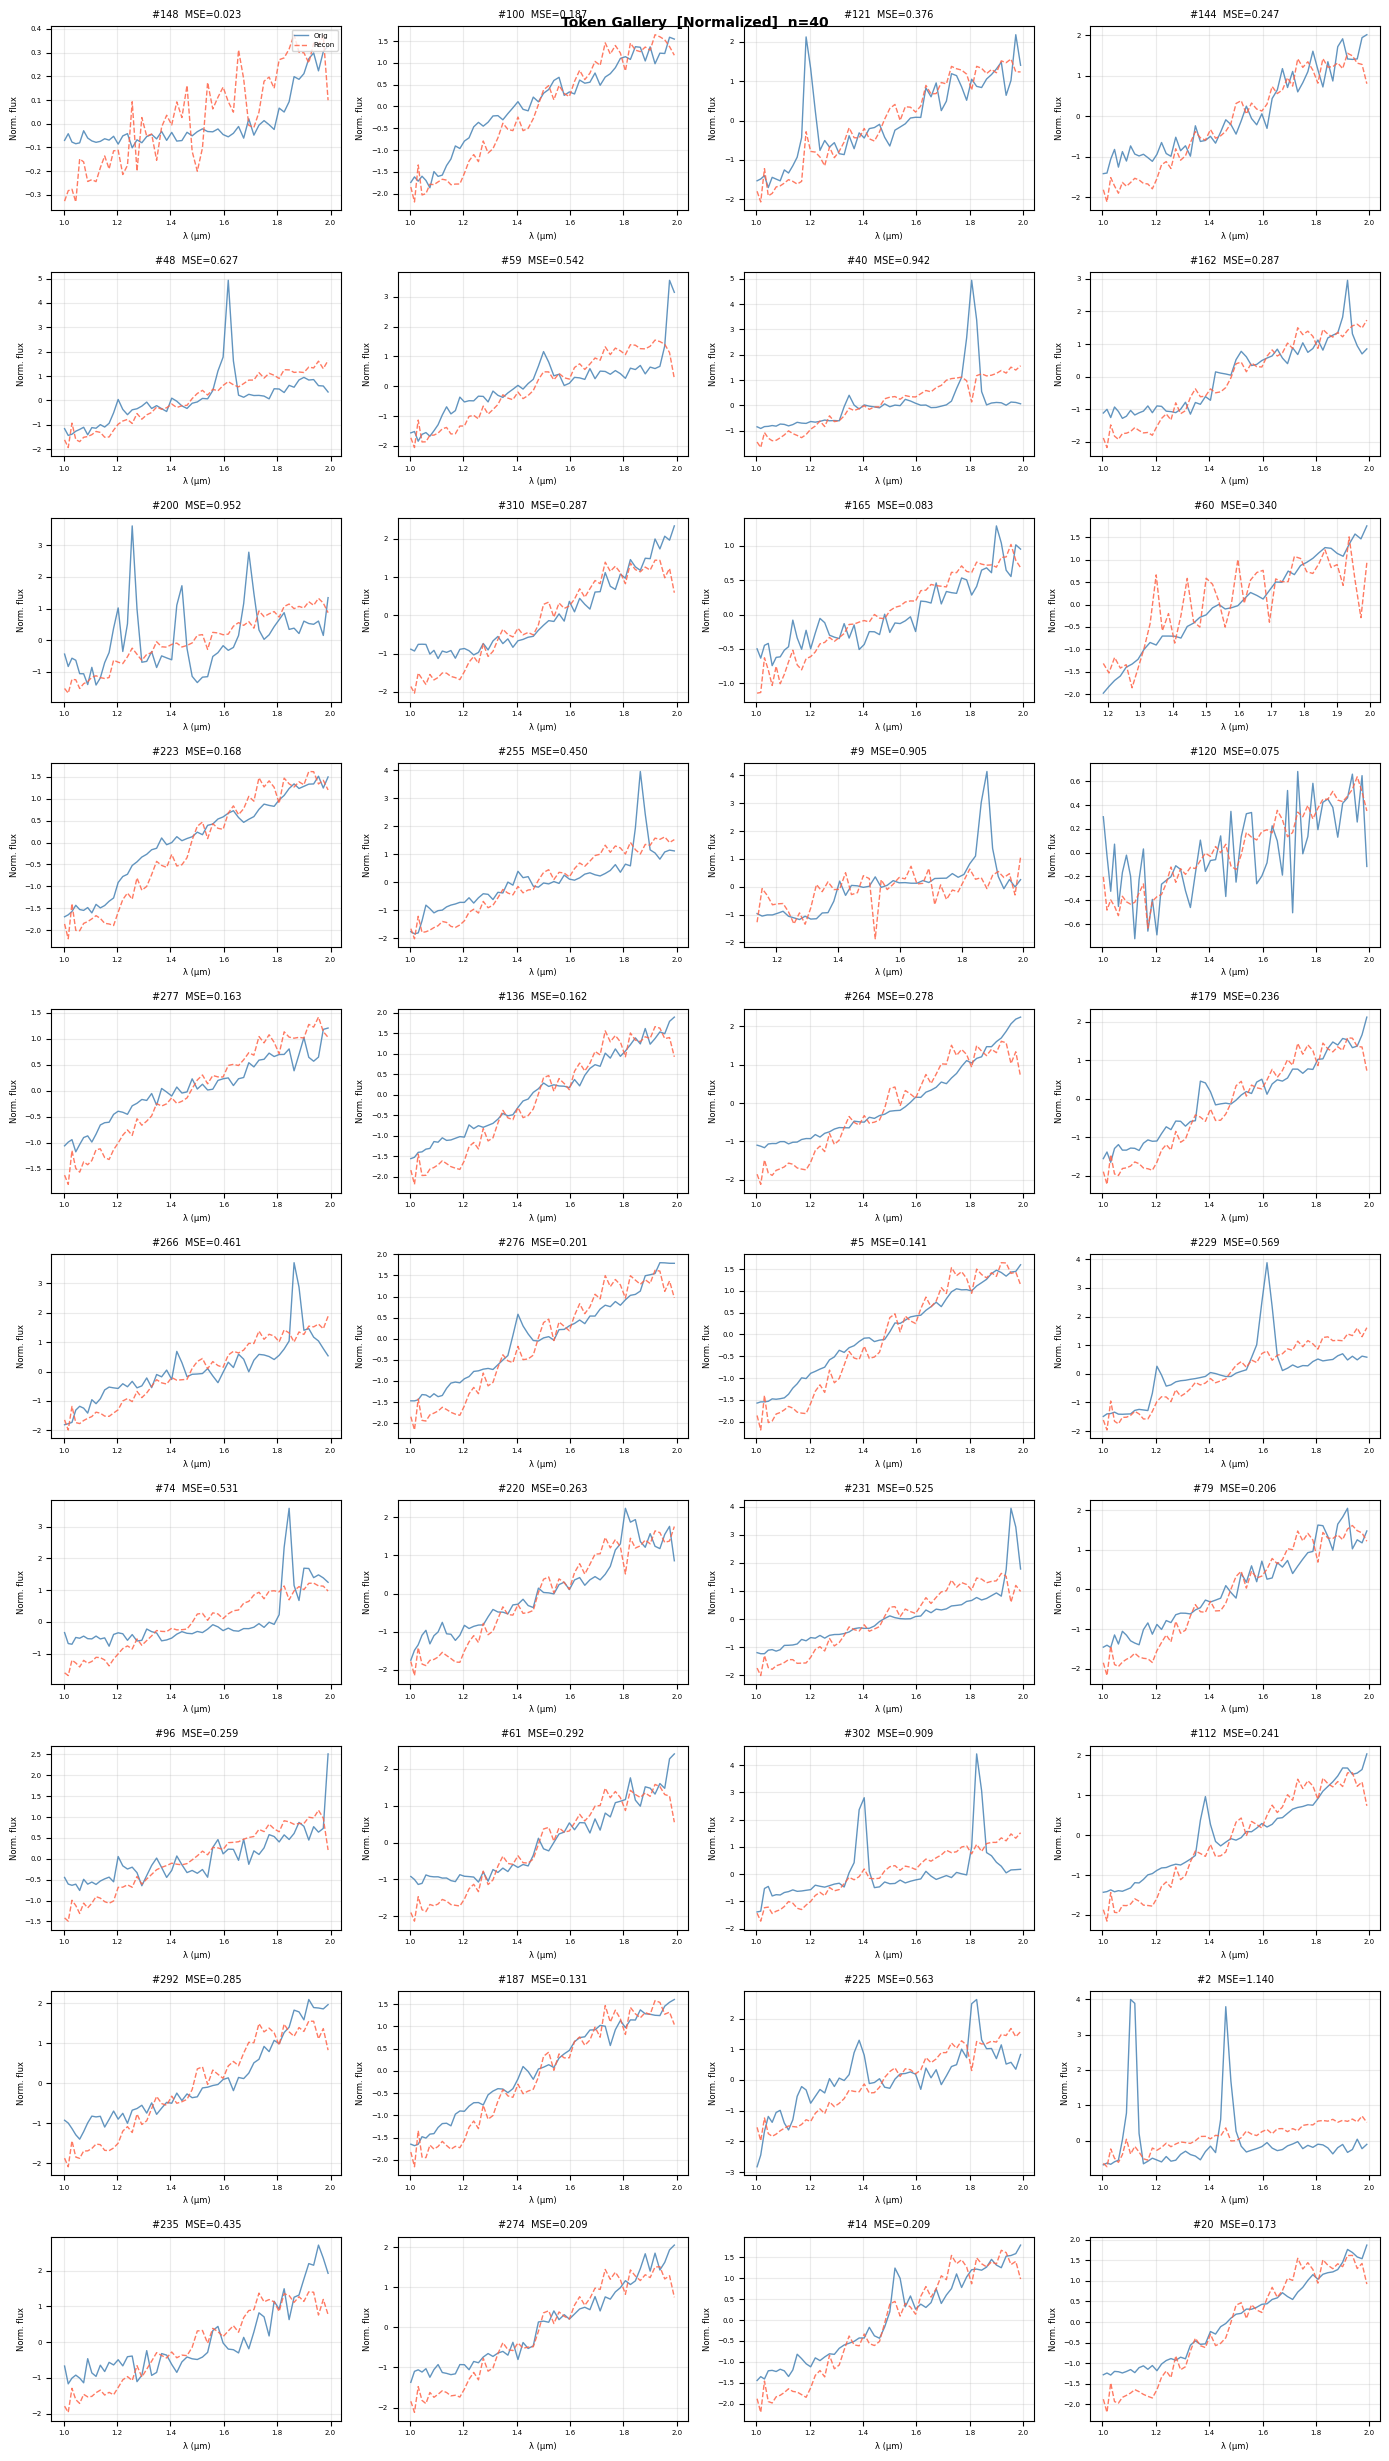

In [5]:
plot_spectra_gallery(results, n_samples=N_GALLERY, recon_key='recon_token', space='normalized')

### 1.2  Statistics: Normalized Space

- **Left**: distribution of per-sample MSE across the collected set  
- **Center**: scatter of all valid pixels (orig_norm vs recon_norm), Pearson r  
- **Right**: residual distribution (recon − orig)

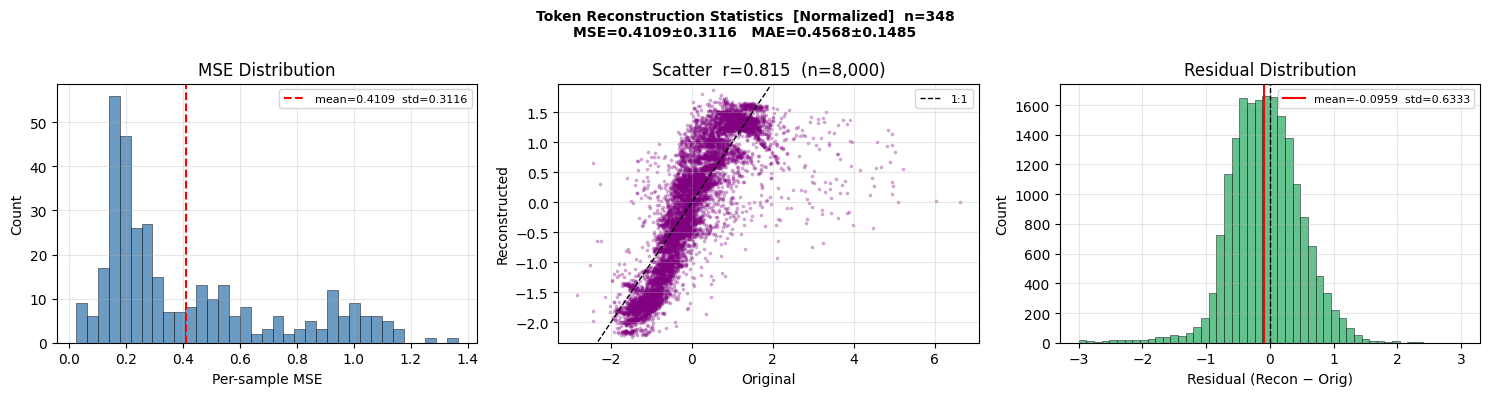

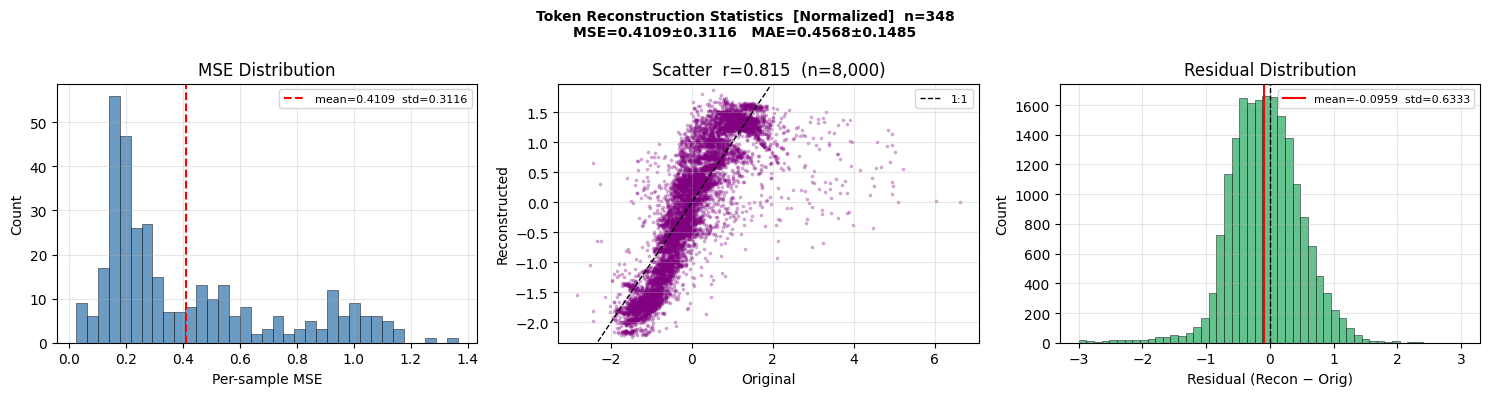

In [6]:

def plot_stats(results, recon_key='recon_token', space='normalized'):
    '''
    Three-panel statistics dashboard.
      Left:   per-sample MSE histogram
      Center: scatter (orig vs recon, all valid pixels)
      Right:  residual distribution (recon − orig)
    '''
    N = results['original'].shape[0]
    mse_list, mae_list, orig_pool, recon_pool = [], [], [], []

    for i in range(N):
        out = _prep(results, i, recon_key, space)
        if out is None:
            continue
        _, orig_s, recon_s, _ = out
        mse_list.append(np.mean((orig_s - recon_s) ** 2))
        mae_list.append(np.mean(np.abs(orig_s - recon_s)))
        orig_pool.append(orig_s)
        recon_pool.append(recon_s)

    mse_arr   = np.array(mse_list)
    mae_arr   = np.array(mae_list)
    orig_all  = np.concatenate(orig_pool)
    recon_all = np.concatenate(recon_pool)
    resid     = recon_all - orig_all

    MAX_PTS = 8000
    if len(orig_all) > MAX_PTS:
        sel = np.random.choice(len(orig_all), MAX_PTS, replace=False)
        o_sc, r_sc = orig_all[sel], recon_all[sel]
    else:
        o_sc, r_sc = orig_all, recon_all
    r_val = np.corrcoef(o_sc, r_sc)[0, 1]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # — MSE histogram
    ax = axes[0]
    ax.hist(mse_arr, bins=35, color='steelblue', alpha=0.8, edgecolor='black', lw=0.4)
    ax.axvline(mse_arr.mean(), color='red', ls='--', lw=1.5,
               label=f'mean={mse_arr.mean():.4f}  std={mse_arr.std():.4f}')
    ax.set_xlabel('Per-sample MSE')
    ax.set_ylabel('Count')
    ax.set_title('MSE Distribution')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # — Scatter
    ax = axes[1]
    ax.scatter(o_sc, r_sc, s=3, alpha=0.25, color='purple', rasterized=True)
    lo = min(o_sc.min(), r_sc.min())
    hi = max(o_sc.max(), r_sc.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1, label='1:1')
    ax.set_ylim(r_sc.min()-0.1, r_sc.max()+0.1)
    ax.set_xlabel('Original')
    ax.set_ylabel('Reconstructed')
    ax.set_title(f'Scatter  r={r_val:.3f}  (n={len(o_sc):,})')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # — Residuals
    ax = axes[2]
    ax.hist(resid, bins=50, color='mediumseagreen', alpha=0.8, edgecolor='black', lw=0.4, range=(-3,3))
    ax.axvline(0,            color='k',   ls='--', lw=1.0)
    ax.axvline(resid.mean(), color='red', ls='-',  lw=1.5,
               label=f'mean={resid.mean():.4f}  std={resid.std():.4f}')
    ax.set_xlabel('Residual (Recon − Orig)')
    ax.set_ylabel('Count')
    ax.set_title('Residual Distribution')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    tag   = 'Token' if recon_key == 'recon_token' else 'CLS'
    stag  = 'Normalized' if space == 'normalized' else 'Physical (uJy)'
    units = '' if space == 'normalized' else ' uJy²'
    plt.suptitle(
        f'{tag} Reconstruction Statistics  [{stag}]  n={N}\n'
        f'MSE={mse_arr.mean():.4f}±{mse_arr.std():.4f}{units}   '
        f'MAE={mae_arr.mean():.4f}±{mae_arr.std():.4f}',
        fontsize=10, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()
    return fig

plot_stats(results, recon_key='recon_token', space='normalized')

### 1.3  Statistics: Physical Space (uJy)

Reconstructions are un-normalized back to flux units: `recon_phys = recon_norm × std + mean`.  
MSE here is in uJy² and scales with source brightness — check if errors are uniform or flux-dependent.

/tmp/ipykernel_21225/4162509605.py:85: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  m     = float(results['mean'][idx])
/tmp/ipykernel_21225/4162509605.py:86: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  s     = float(results['std'][idx])


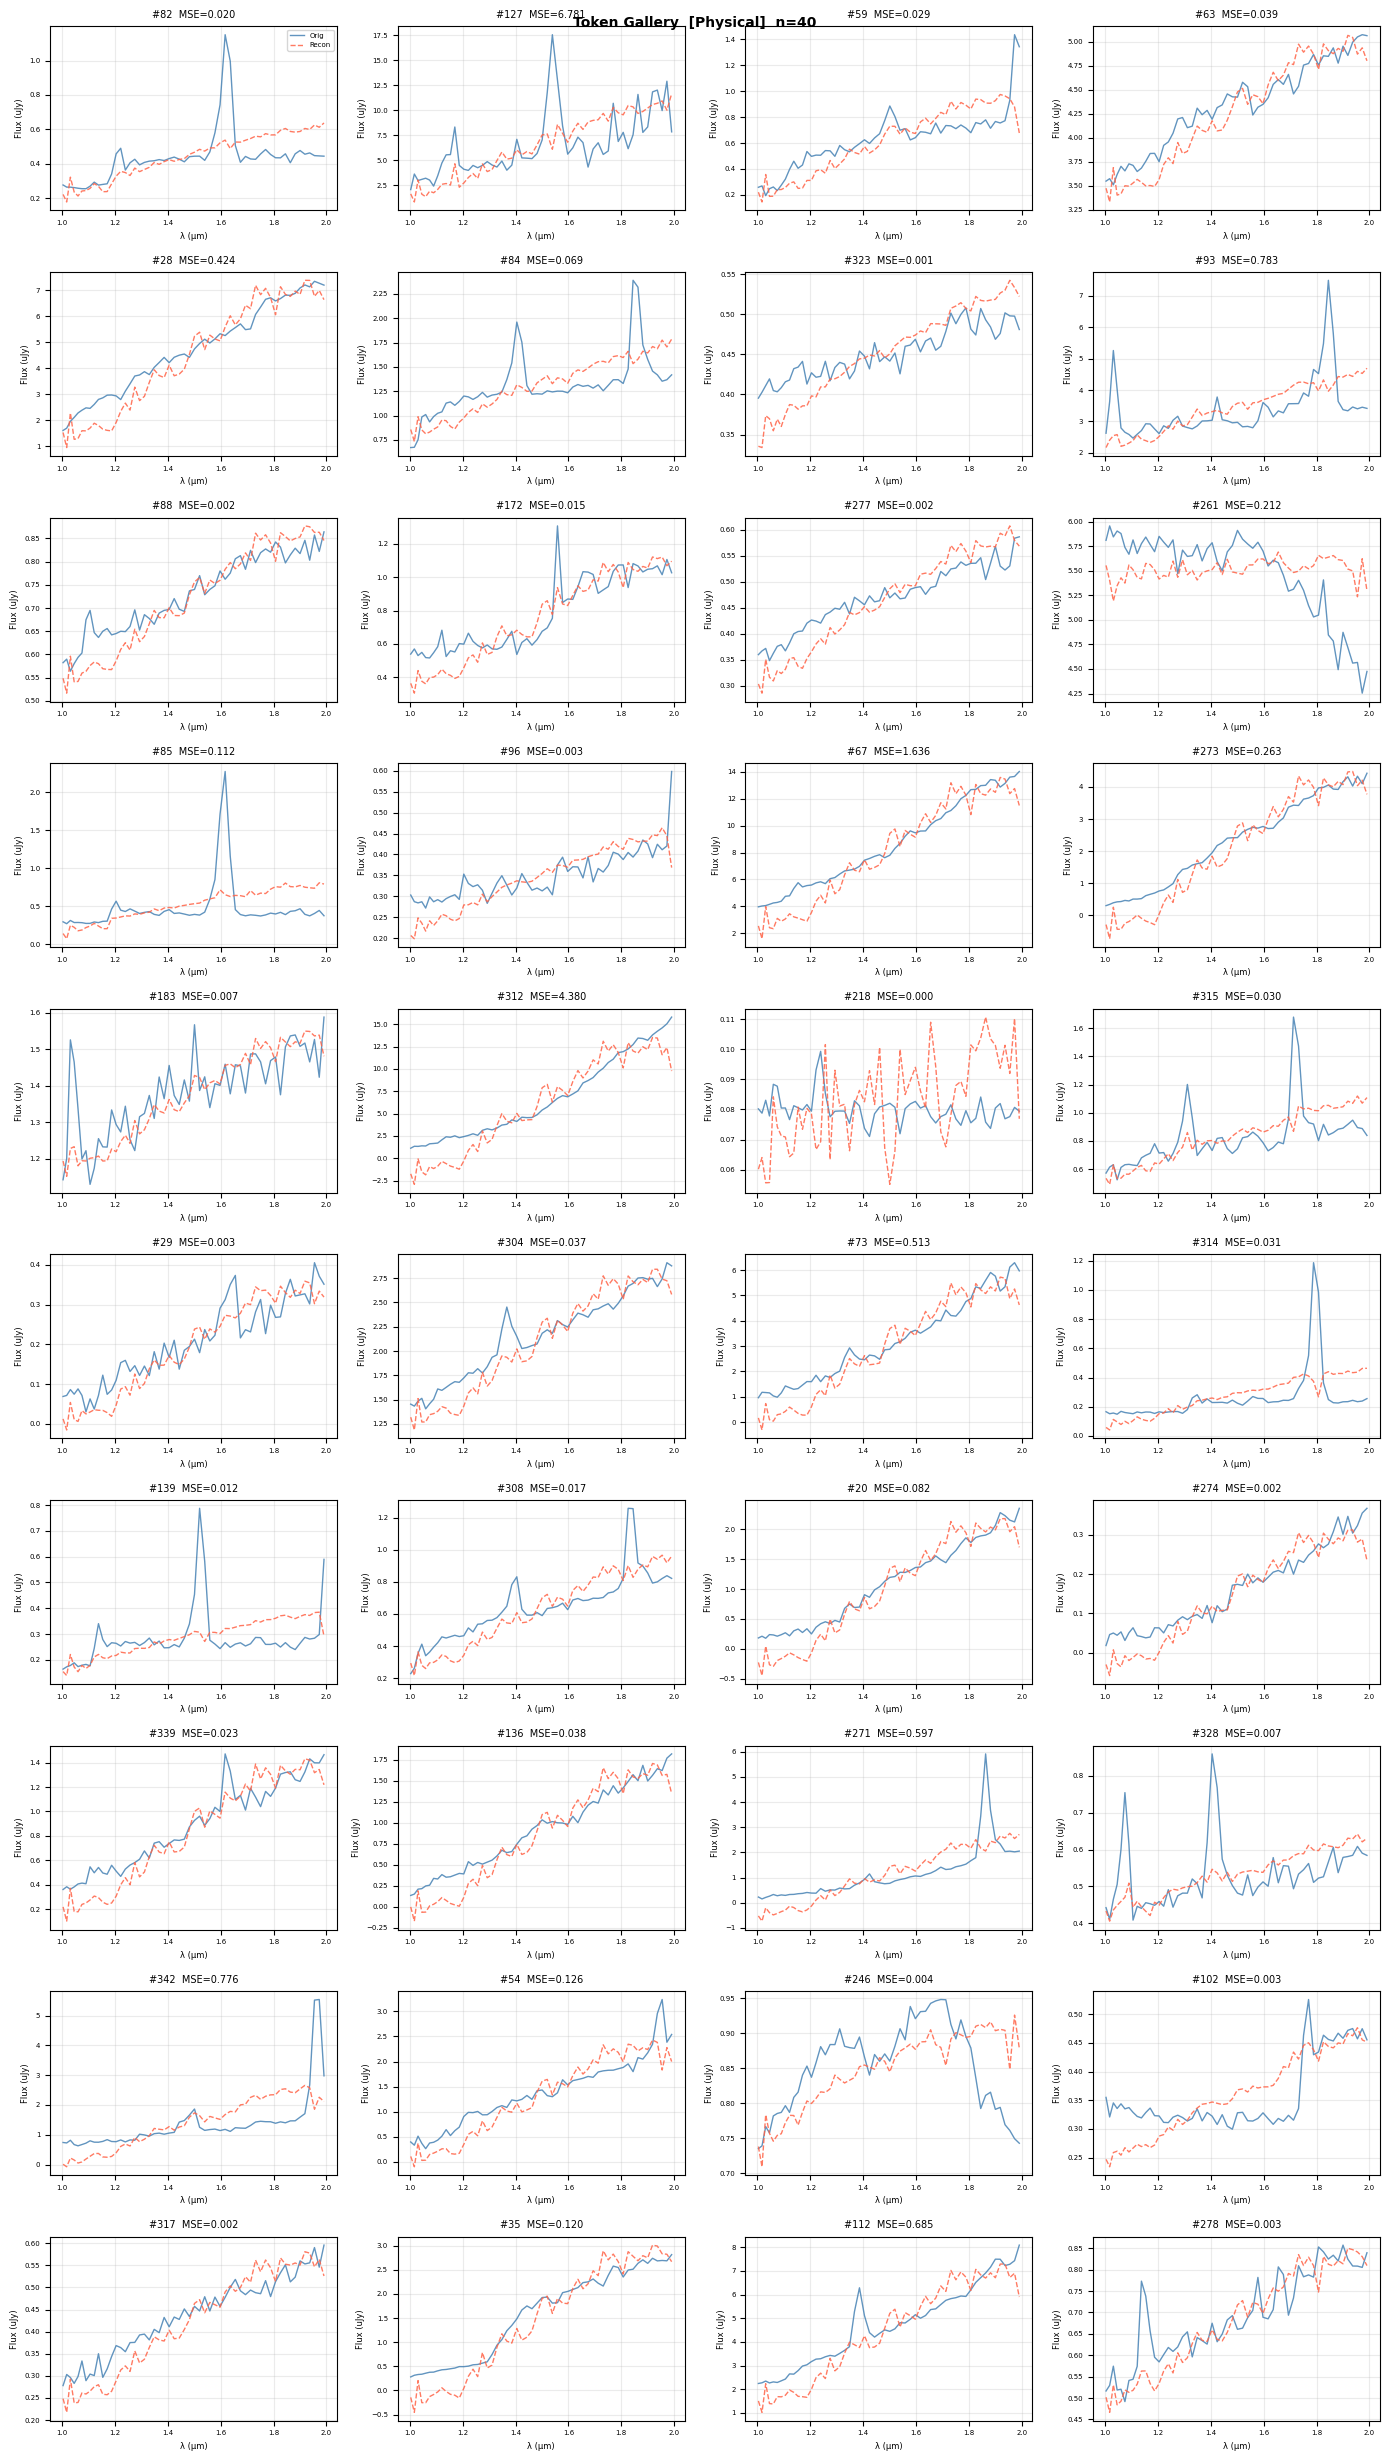

In [7]:
plot_spectra_gallery(results, n_samples=N_GALLERY, recon_key='recon_token', space='physical')

/tmp/ipykernel_21225/4162509605.py:85: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  m     = float(results['mean'][idx])
/tmp/ipykernel_21225/4162509605.py:86: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  s     = float(results['std'][idx])


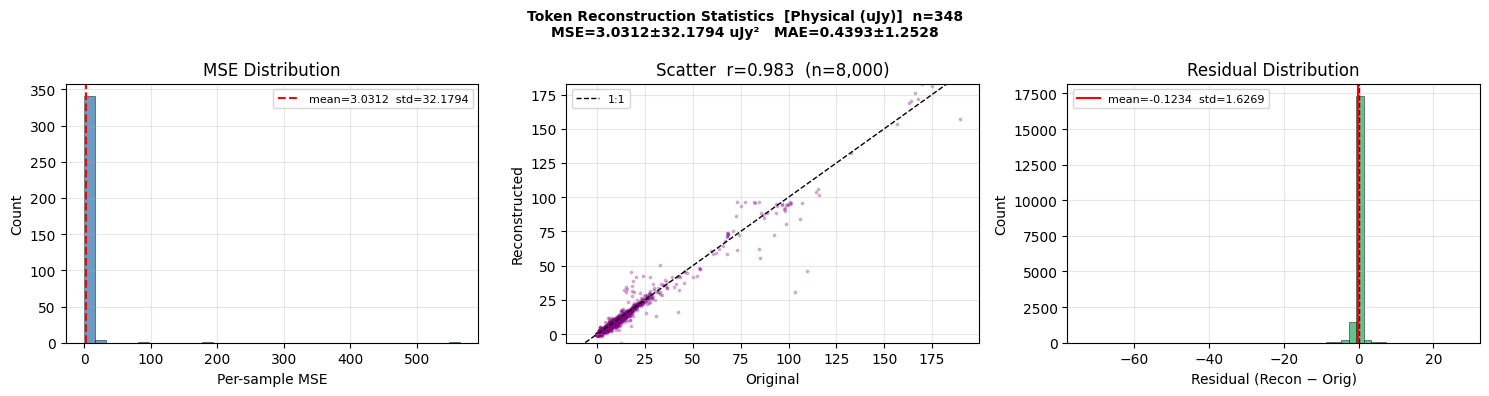

In [8]:
def plot_stats(results, recon_key='recon_token', space='normalized'):
    '''
    Three-panel statistics dashboard.
      Left:   per-sample MSE histogram
      Center: scatter (orig vs recon, all valid pixels)
      Right:  residual distribution (recon − orig)
    '''
    N = results['original'].shape[0]
    mse_list, mae_list, orig_pool, recon_pool = [], [], [], []

    for i in range(N):
        out = _prep(results, i, recon_key, space)
        if out is None:
            continue
        _, orig_s, recon_s, _ = out
        mse_list.append(np.mean((orig_s - recon_s) ** 2))
        mae_list.append(np.mean(np.abs(orig_s - recon_s)))
        orig_pool.append(orig_s)
        recon_pool.append(recon_s)

    mse_arr   = np.array(mse_list)
    mae_arr   = np.array(mae_list)
    orig_all  = np.concatenate(orig_pool)
    recon_all = np.concatenate(recon_pool)
    resid     = recon_all - orig_all

    MAX_PTS = 8000
    if len(orig_all) > MAX_PTS:
        sel = np.random.choice(len(orig_all), MAX_PTS, replace=False)
        o_sc, r_sc = orig_all[sel], recon_all[sel]
    else:
        o_sc, r_sc = orig_all, recon_all
    r_val = np.corrcoef(o_sc, r_sc)[0, 1]

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    # — MSE histogram
    ax = axes[0]
    ax.hist(mse_arr, bins=35, color='steelblue', alpha=0.8, edgecolor='black', lw=0.4)
    ax.axvline(mse_arr.mean(), color='red', ls='--', lw=1.5,
               label=f'mean={mse_arr.mean():.4f}  std={mse_arr.std():.4f}')
    ax.set_xlabel('Per-sample MSE')
    ax.set_ylabel('Count')
    ax.set_title('MSE Distribution')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # — Scatter
    ax = axes[1]
    ax.scatter(o_sc, r_sc, s=3, alpha=0.25, color='purple', rasterized=True)
    lo = min(o_sc.min(), r_sc.min())
    hi = max(o_sc.max(), r_sc.max())
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1, label='1:1')
    ax.set_ylim(r_sc.min()-0.1, r_sc.max()+0.1)
    ax.set_xlabel('Original')
    ax.set_ylabel('Reconstructed')
    ax.set_title(f'Scatter  r={r_val:.3f}  (n={len(o_sc):,})')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    # — Residuals
    ax = axes[2]
    ax.hist(resid, bins=50, color='mediumseagreen', alpha=0.8, edgecolor='black', lw=0.4)
    ax.axvline(0,            color='k',   ls='--', lw=1.0)
    ax.axvline(resid.mean(), color='red', ls='-',  lw=1.5,
               label=f'mean={resid.mean():.4f}  std={resid.std():.4f}')
    ax.set_xlabel('Residual (Recon − Orig)')
    ax.set_ylabel('Count')
    ax.set_title('Residual Distribution')
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

    tag   = 'Token' if recon_key == 'recon_token' else 'CLS'
    stag  = 'Normalized' if space == 'normalized' else 'Physical (uJy)'
    units = '' if space == 'normalized' else ' uJy²'
    plt.suptitle(
        f'{tag} Reconstruction Statistics  [{stag}]  n={N}\n'
        f'MSE={mse_arr.mean():.4f}±{mse_arr.std():.4f}{units}   '
        f'MAE={mae_arr.mean():.4f}±{mae_arr.std():.4f}',
        fontsize=10, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()
    
plot_stats(results, recon_key='recon_token', space='physical')

---
## Section 2 — CLS Token Reconstruction

The CLS head decodes the **entire spectrum from a single global embedding**:  
`cat([cls_embedding, pos_emb(λ)])` → 2-layer MLP → flux at each wavelength.

Loss during training covers **all valid positions** (information bottleneck):  
the only path from the full spectrum to any per-pixel prediction is through the CLS token.

Expect higher MSE than the token head (global → local is harder), but check whether the  
CLS head tracks the overall spectral shape (r ≈ token r) — if yes, CLS is a good global representation.

### 2.1  Spectrum Gallery (normalized)

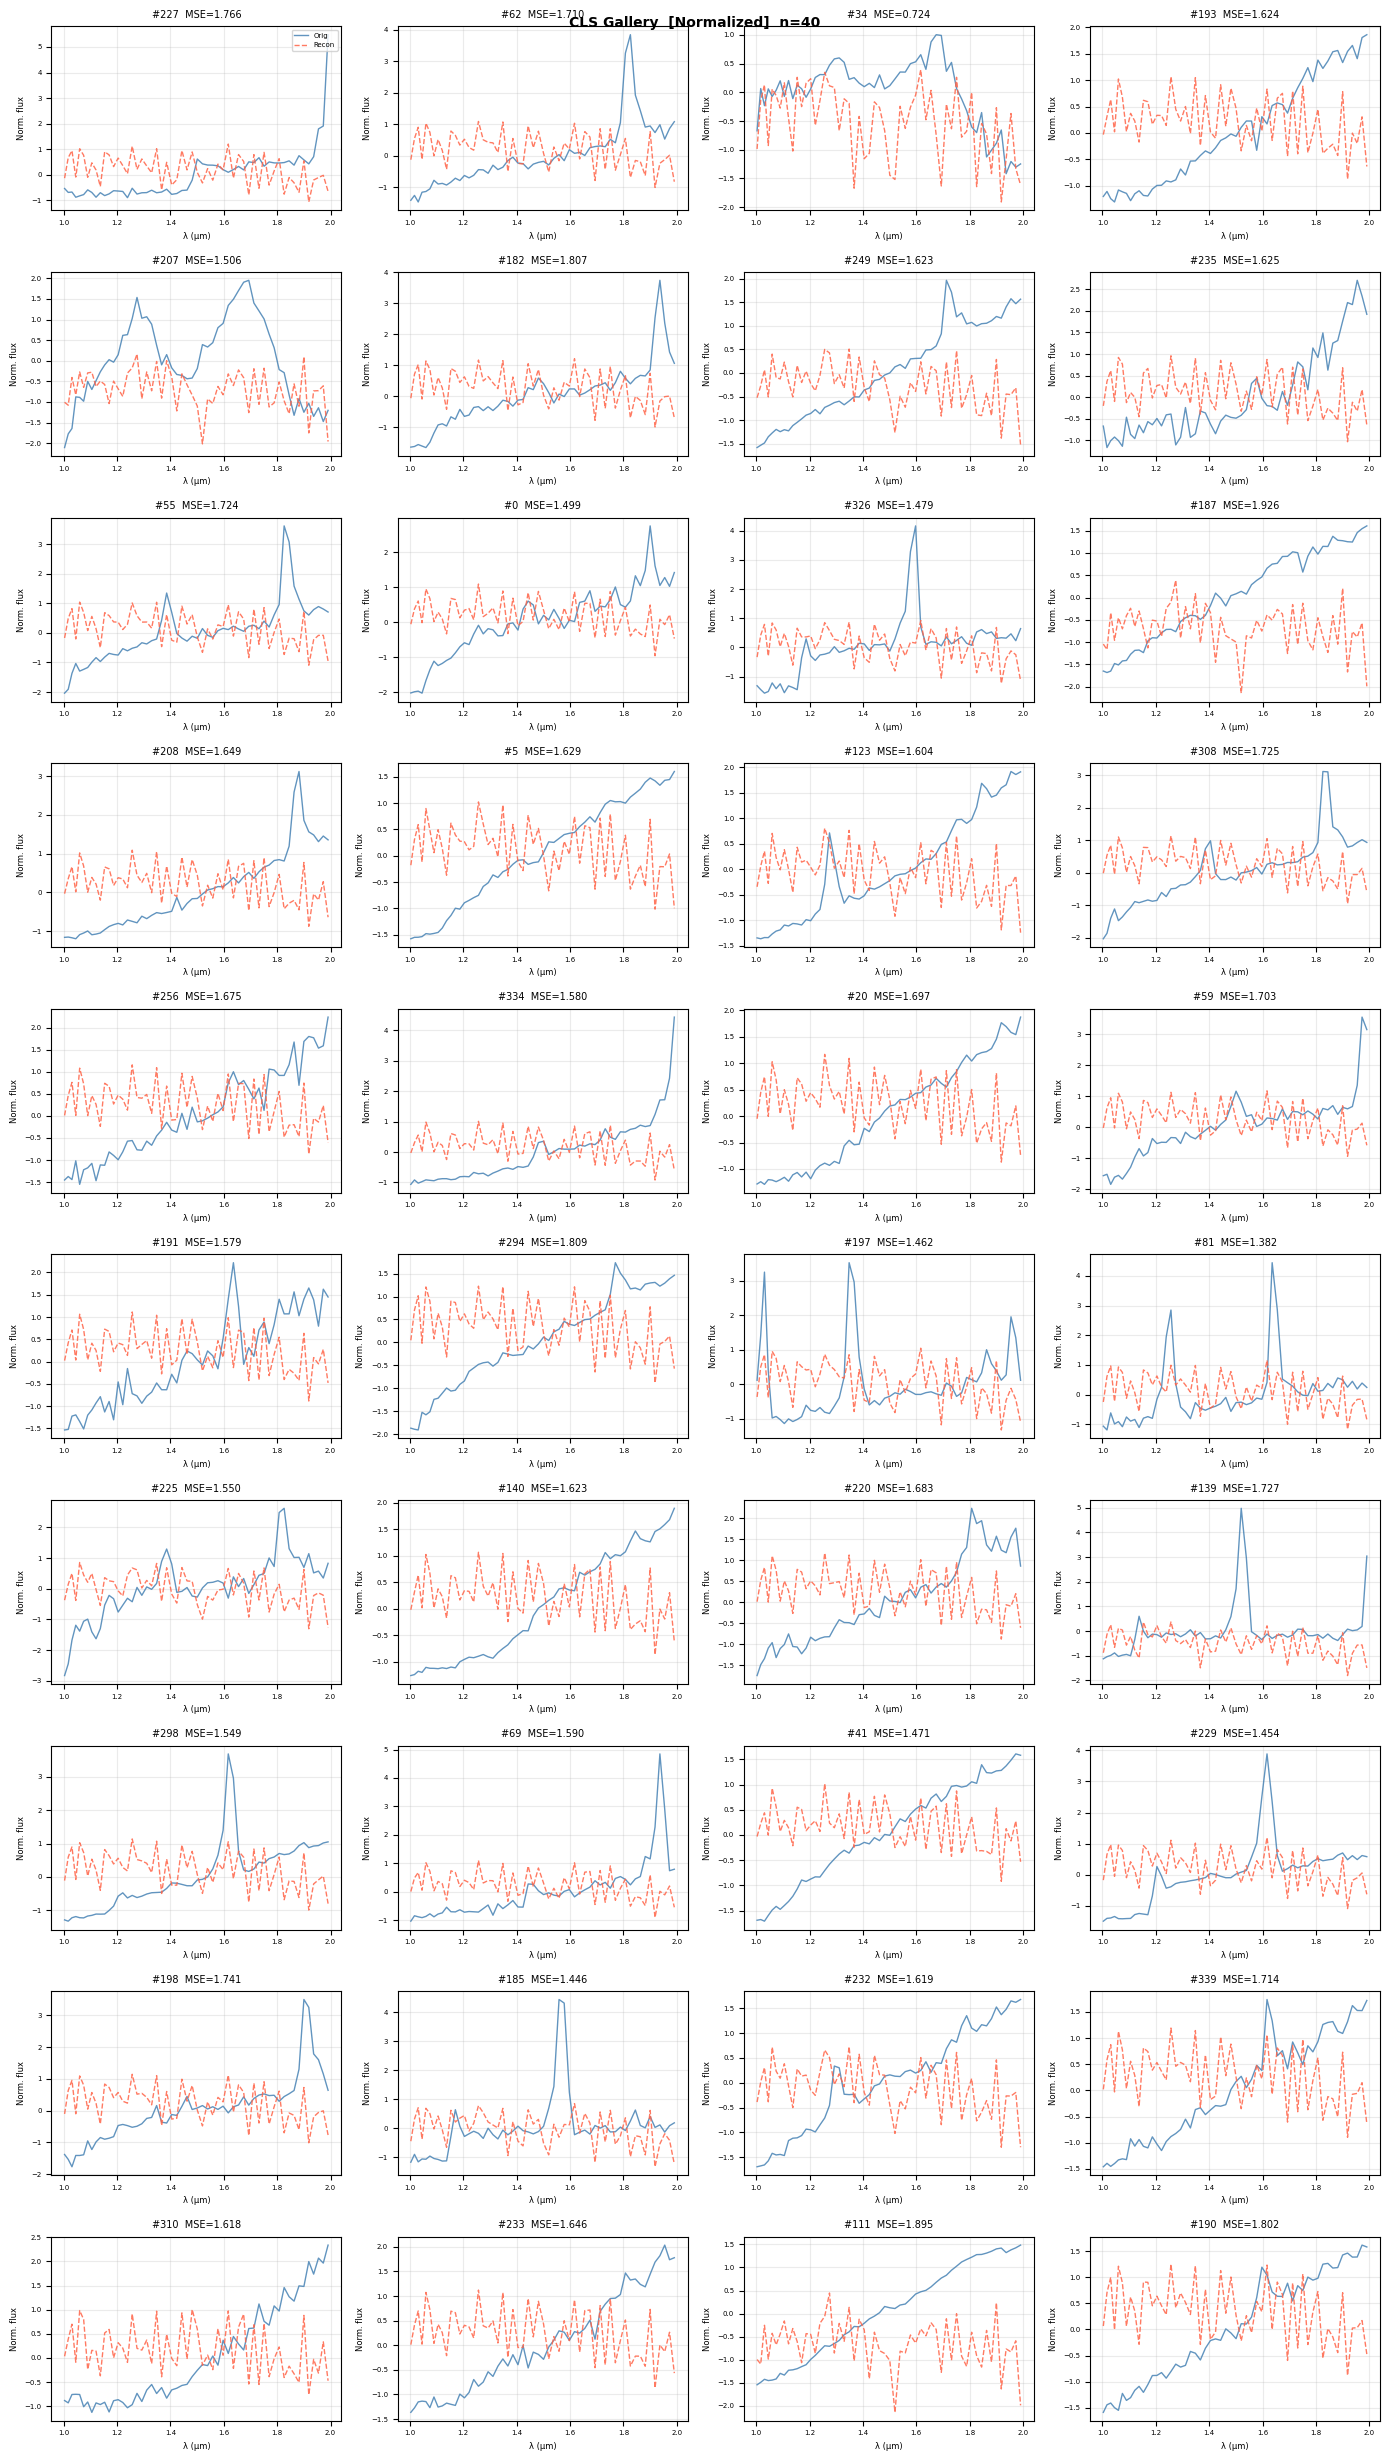

In [9]:
plot_spectra_gallery(results, n_samples=N_GALLERY, recon_key='recon_cls', space='normalized')

### 2.2  Statistics: Normalized Space

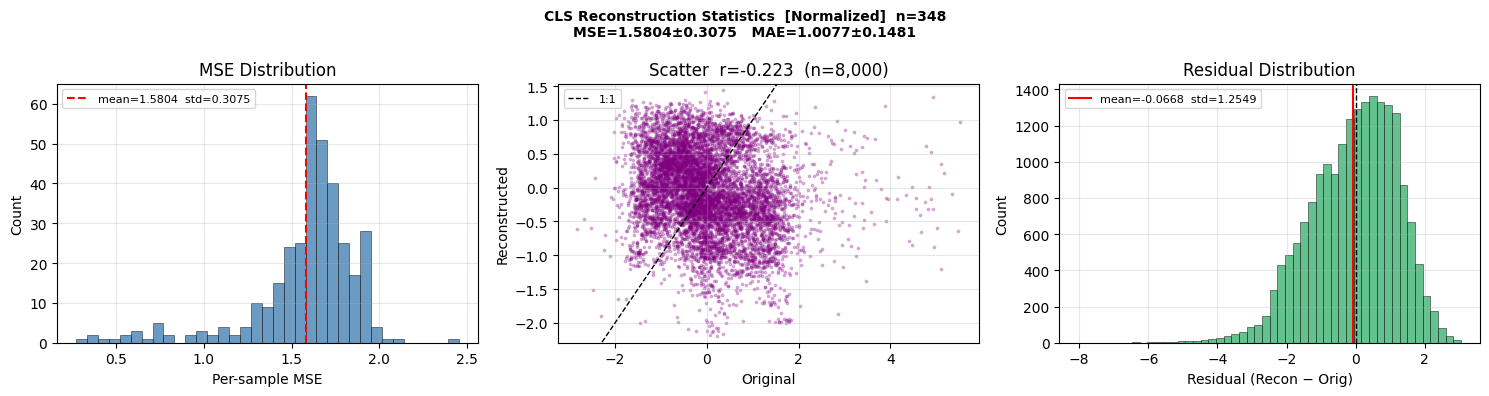

In [10]:
plot_stats(results, recon_key='recon_cls', space='normalized')

### 2.3  Statistics: Physical Space (uJy)

/tmp/ipykernel_21225/4162509605.py:85: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  m     = float(results['mean'][idx])
/tmp/ipykernel_21225/4162509605.py:86: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  s     = float(results['std'][idx])


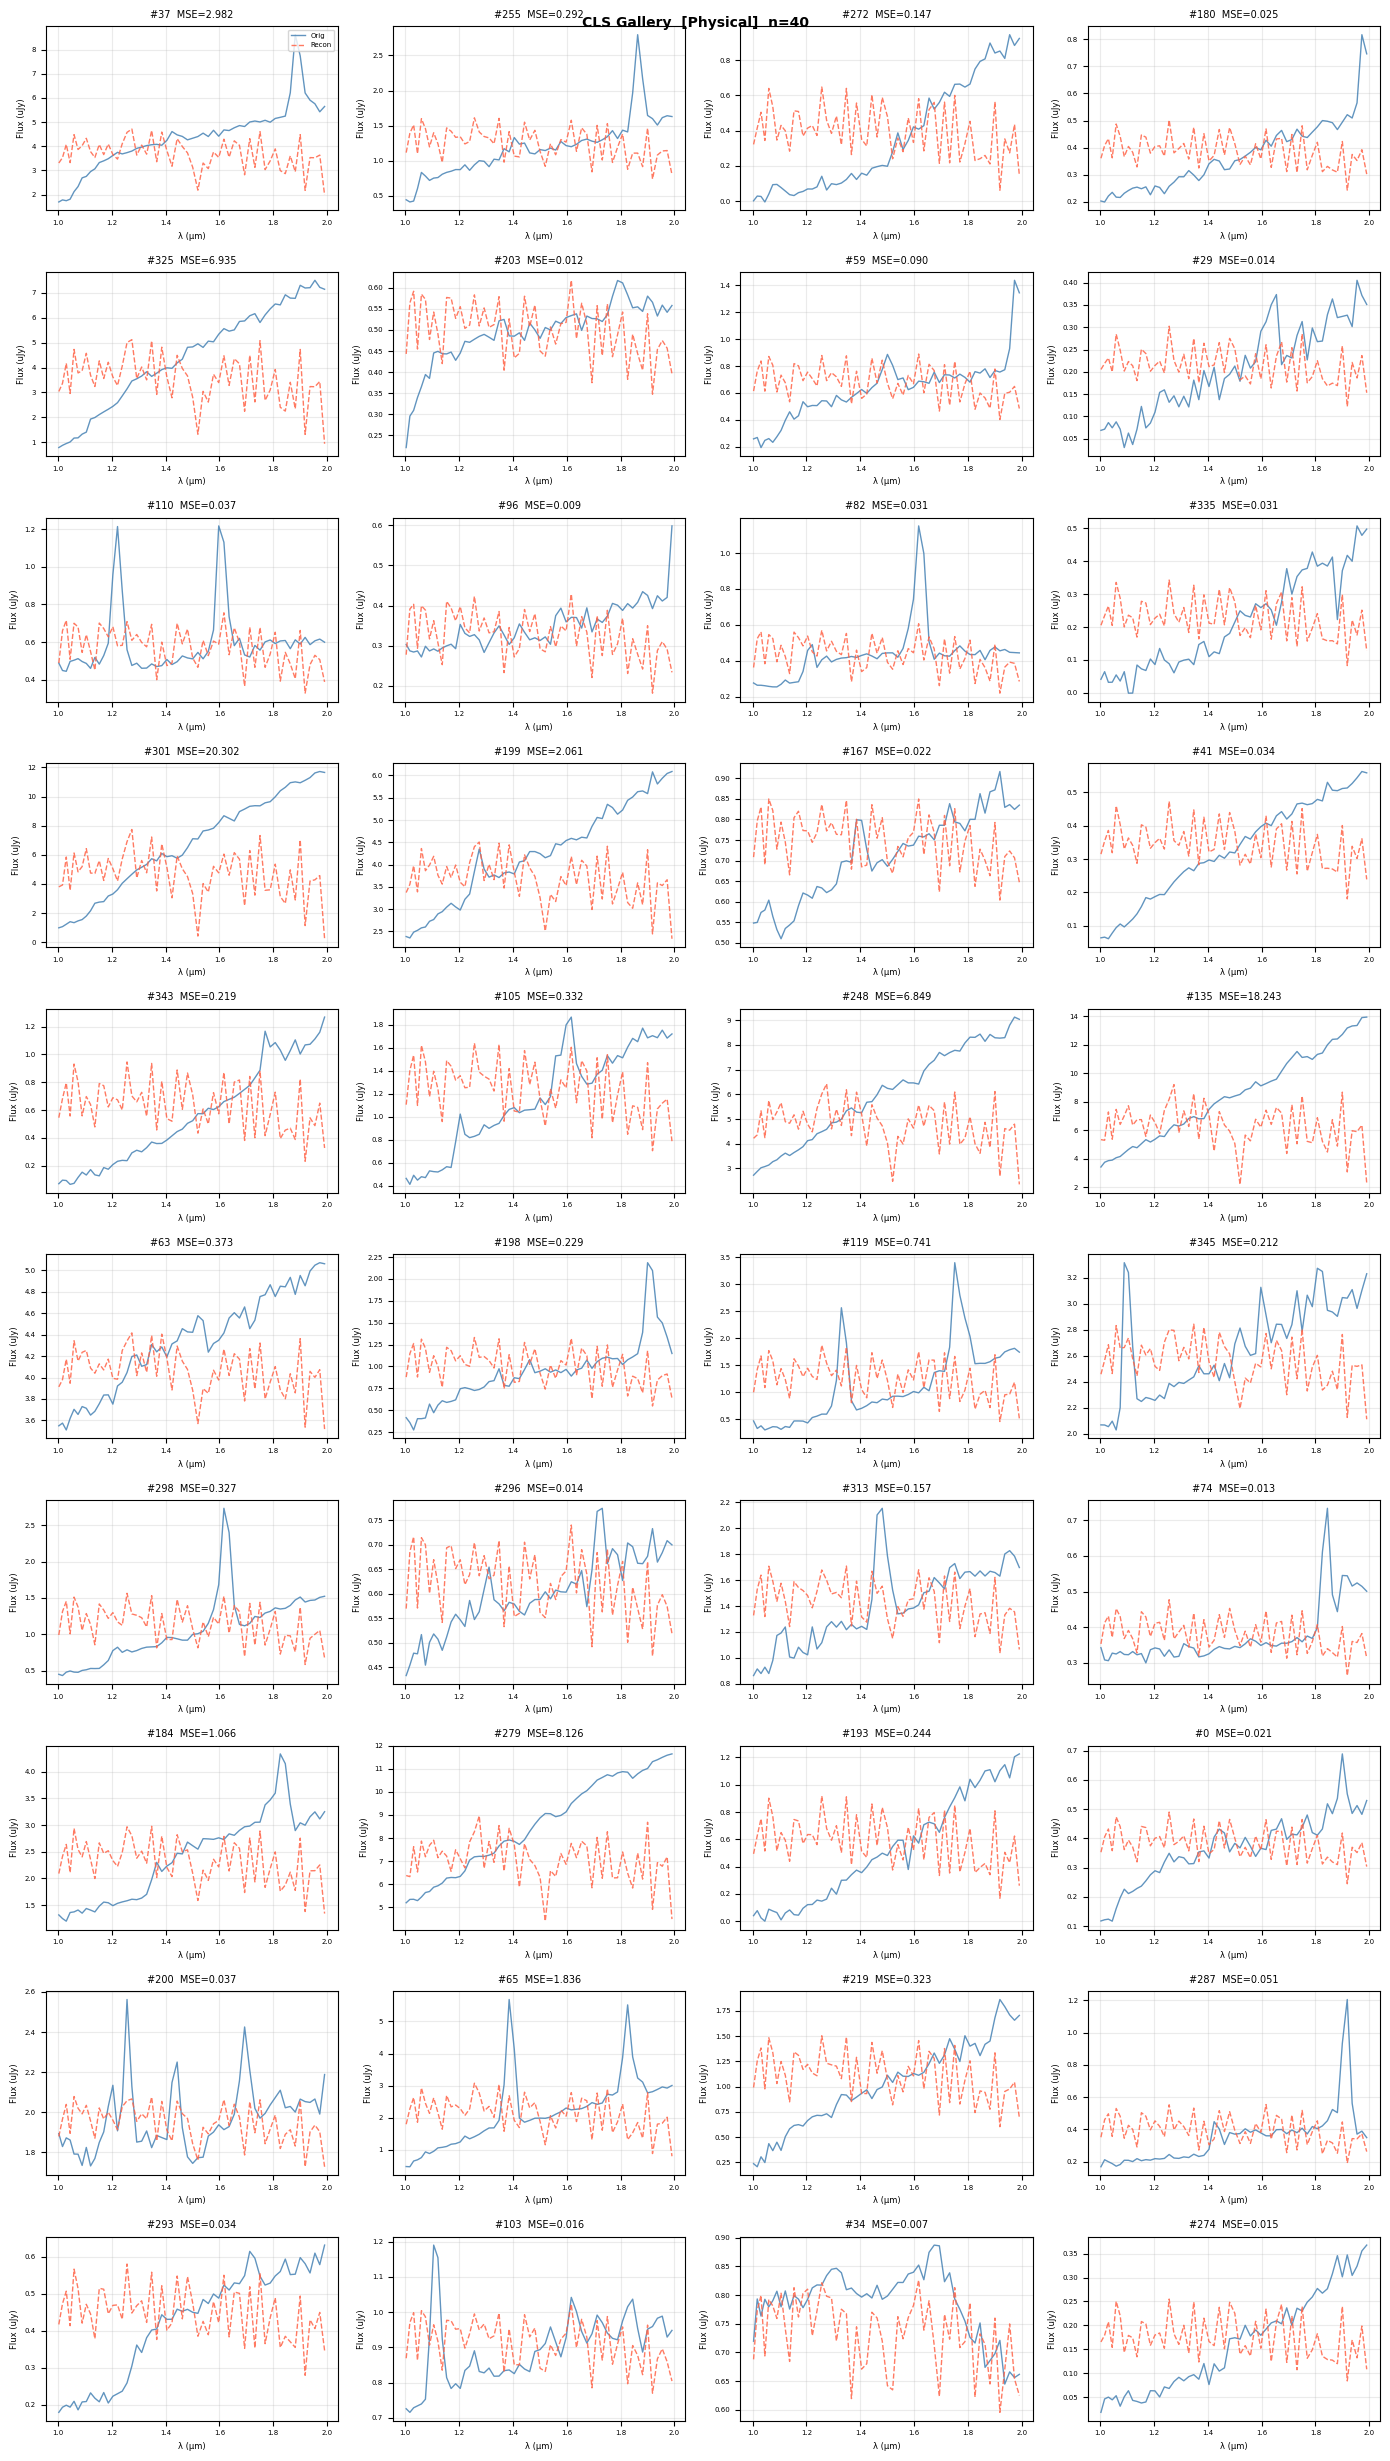

In [11]:
plot_spectra_gallery(results, n_samples=N_GALLERY, recon_key='recon_cls', space='physical')

/tmp/ipykernel_21225/4162509605.py:85: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  m     = float(results['mean'][idx])
/tmp/ipykernel_21225/4162509605.py:86: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  s     = float(results['std'][idx])


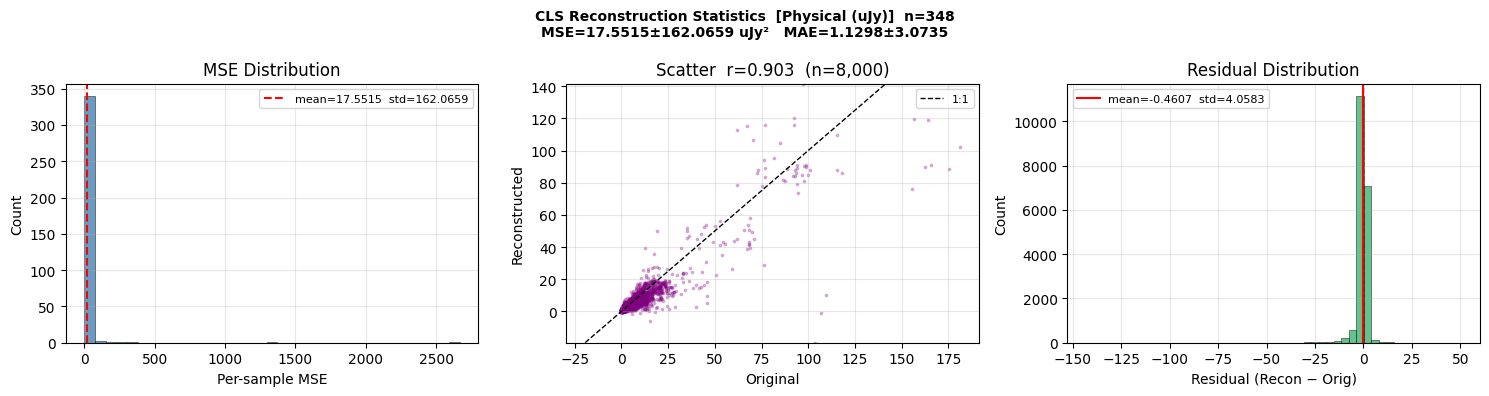

In [12]:
plot_stats(results, recon_key='recon_cls', space='physical')

---
## Section 3 — Summary

Side-by-side comparison of Token head vs CLS head across both spaces.

In [13]:
print_summary(results)


Summary  (n=348 val samples)
Head       MSE_norm       ±   MAE_norm       ±     MSE_phys         ±
─────────────────────────────────────────────────────────────────────
Token        0.4109  0.3116     0.4568  0.1485         3.03     32.18
CLS          1.5804  0.3075     1.0077  0.1481        17.55    162.07


/tmp/ipykernel_21225/4162509605.py:85: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  m     = float(results['mean'][idx])
/tmp/ipykernel_21225/4162509605.py:86: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  s     = float(results['std'][idx])


---
## Section 4 — Outlier Analysis: Original >> Reconstruction

For both heads, we find pixels / samples where the model **significantly underpredicts** the original flux
(points far to the right of the 1:1 line, i.e. `original >> recon`).

**Outlier metric:** per-sample `max(orig_norm − recon_norm)` over valid pixels — ranks samples by their worst single-pixel underprediction.

Each sub-section shows:
1. **Scatter with outlier pixels highlighted** — pixels where `orig − recon > 2σ` are marked red
2. **Example gallery** — the top-N worst-outlier spectra, with outlier pixels flagged

In [14]:
# ── Outlier detection helpers ─────────────────────────────────────────────────

N_OUTLIERS      = 16    # how many worst-case samples to show in gallery
OUTLIER_SIGMA   = 2.0   # pixel-level threshold: orig - recon > N*global_std → outlier pixel
PIXEL_FLAG_THR  = 1.5   # per-spectrum threshold (in normalized units) to flag individual pixels in gallery


def _collect_pixel_arrays(results, recon_key, space='normalized'):
    """Stack all valid pixels from all samples. Returns orig, recon, sample_ids arrays."""
    orig_pool, recon_pool, sid_pool = [], [], []
    for i in range(results['original'].shape[0]):
        out = _prep(results, i, recon_key, space)
        if out is None:
            continue
        _, orig_s, recon_s, _ = out
        orig_pool.append(orig_s)
        recon_pool.append(recon_s)
        sid_pool.append(np.full(len(orig_s), i, dtype=np.int32))
    return (np.concatenate(orig_pool),
            np.concatenate(recon_pool),
            np.concatenate(sid_pool))


def find_outlier_samples(results, recon_key='recon_token', n_outliers=12):
    """
    Rank samples by max(orig_norm - recon_norm) over valid pixels.
    Returns (sorted indices, scores) — worst first.
    """
    N = results['original'].shape[0]
    scores = np.zeros(N)
    for i in range(N):
        out = _prep(results, i, recon_key, 'normalized')
        if out is None:
            continue
        _, orig_s, recon_s, _ = out
        scores[i] = float((orig_s - recon_s).max())
    order = np.argsort(scores)[::-1]
    return order[:n_outliers], scores[order[:n_outliers]]


def plot_outlier_scatter(results, recon_key='recon_token', threshold_sigma=2.0):
    """
    Scatter (orig vs recon, normalized) with pixels where orig-recon > threshold highlighted in red.
    """
    orig_all, recon_all, _ = _collect_pixel_arrays(results, recon_key, 'normalized')
    pos_resid  = orig_all - recon_all          # positive = model underpredicts
    threshold  = threshold_sigma * pos_resid.std()
    is_outlier = pos_resid > threshold

    MAX_PTS = 6000
    normal_idx = np.where(~is_outlier)[0]
    if len(normal_idx) > MAX_PTS:
        normal_idx = np.random.choice(normal_idx, MAX_PTS, replace=False)

    fig, ax = plt.subplots(figsize=(6, 5))
    ax.scatter(orig_all[normal_idx], recon_all[normal_idx],
               s=3, alpha=0.2, color='purple', rasterized=True, label='Normal')
    ax.scatter(orig_all[is_outlier], recon_all[is_outlier],
               s=10, alpha=0.55, color='red', rasterized=True,
               label=f'Outlier  orig−recon > {threshold_sigma}σ ({threshold:.2f})')

    lo = min(orig_all.min(), recon_all.min()) - 0.1
    hi = max(orig_all.max(), recon_all.max()) + 0.1
    ax.plot([lo, hi], [lo, hi], 'k--', lw=1.2, label='1:1')

    tag = 'Token' if recon_key == 'recon_token' else 'CLS'
    ax.set_xlabel('Original (normalized)')
    ax.set_ylabel('Reconstructed (normalized)')
    ax.set_title(
        f'{tag} — Scatter with Outlier Pixels\n'
        f'Outliers: {is_outlier.sum():,} / {len(orig_all):,}  '
        f'({100*is_outlier.mean():.1f}%)',
        fontsize=10
    )
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_outlier_gallery(results, recon_key='recon_token',
                         n_outliers=12, pixel_flag_thr=1.5,
                         panel_w=4.0, panel_h=2.8, max_cols=4):
    """
    Gallery of the worst-outlier samples. Outlier pixels (orig−recon > pixel_flag_thr)
    are marked with red dots (original position) and orange × (reconstructed position).
    """
    outlier_idx, scores = find_outlier_samples(results, recon_key, n_outliers=n_outliers)

    n_rows, n_cols = _grid_dims(len(outlier_idx), max_cols=max_cols)
    fig, axes = plt.subplots(n_rows, n_cols,
                              figsize=(panel_w * n_cols, panel_h * n_rows),
                              squeeze=False)
    flat = axes.flatten()

    for ai, (idx, score) in enumerate(zip(outlier_idx, scores)):
        ax  = flat[ai]
        out = _prep(results, idx, recon_key, 'normalized')
        if out is None:
            ax.set_visible(False)
            continue
        wl_s, orig_s, recon_s, ylab = out
        bad = (orig_s - recon_s) > pixel_flag_thr   # per-pixel outlier flag

        ax.plot(wl_s, orig_s,  color='steelblue', lw=1.2, alpha=0.9, label='Orig')
        ax.plot(wl_s, recon_s, color='tomato',    lw=1.2, alpha=0.9, ls='--', label='Recon')
        if bad.any():
            ax.scatter(wl_s[bad], orig_s[bad],
                       color='red',    s=30, zorder=5, label=f'outlier px ({bad.sum()})')
            ax.scatter(wl_s[bad], recon_s[bad],
                       color='orange', s=30, marker='x', zorder=5)

        ax.set_title(f'#{idx}  max(orig−recon)={score:.2f}', fontsize=7)
        ax.set_xlabel('λ (µm)', fontsize=6)
        ax.set_ylabel(ylab, fontsize=6)
        ax.tick_params(labelsize=5)
        ax.grid(alpha=0.25)
        if ai == 0:
            ax.legend(fontsize=5, loc='upper right')

    for ai in range(len(outlier_idx), len(flat)):
        flat[ai].set_visible(False)

    tag = 'Token' if recon_key == 'recon_token' else 'CLS'
    plt.suptitle(
        f'{tag} — Top-{len(outlier_idx)} Outlier Samples  '
        f'(Original >> Reconstruction)\n'
        f'Red dots = orig, orange × = recon at outlier pixels (orig−recon > {pixel_flag_thr:.1f})',
        fontsize=9, fontweight='bold'
    )
    plt.tight_layout()
    plt.show()


print('Outlier helpers loaded.')

Outlier helpers loaded.


### 4.1  Token Head — Outlier Scatter + Gallery

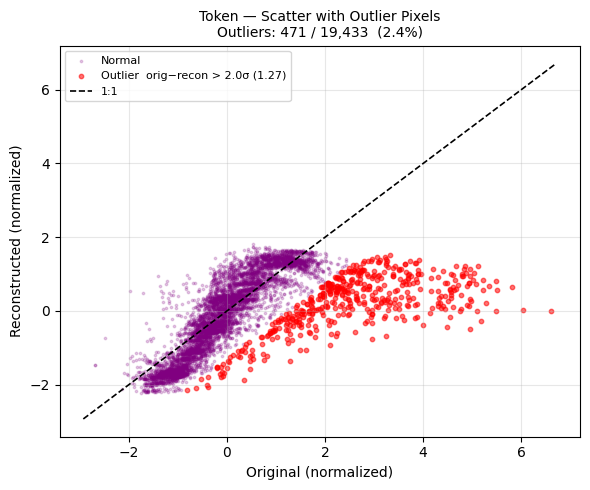

In [15]:
plot_outlier_scatter(results, recon_key='recon_token', threshold_sigma=OUTLIER_SIGMA)

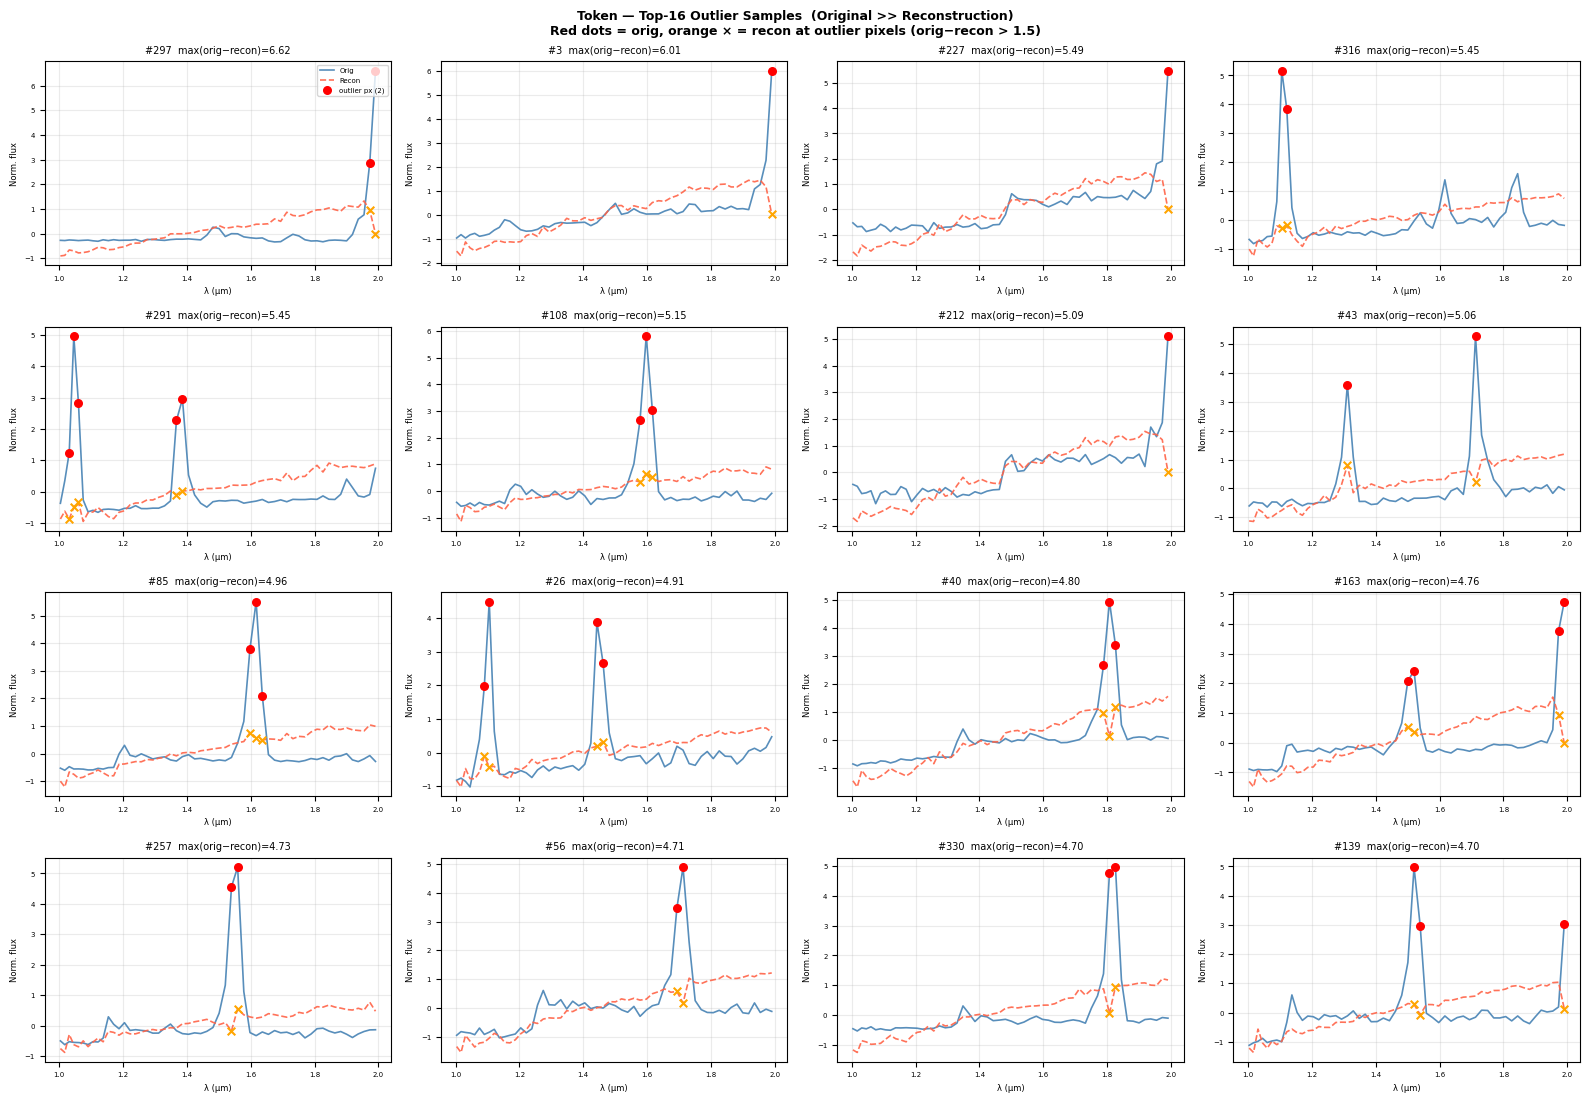

In [16]:
plot_outlier_gallery(results, recon_key='recon_token',
                     n_outliers=N_OUTLIERS, pixel_flag_thr=PIXEL_FLAG_THR)

### 4.2  CLS Head — Outlier Scatter + Gallery

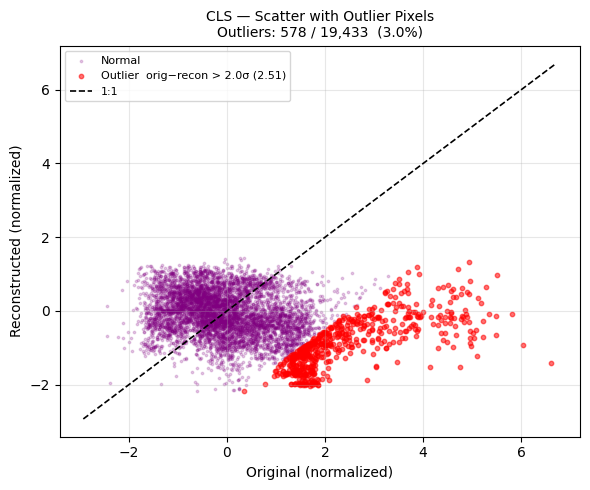

In [17]:
plot_outlier_scatter(results, recon_key='recon_cls', threshold_sigma=OUTLIER_SIGMA)

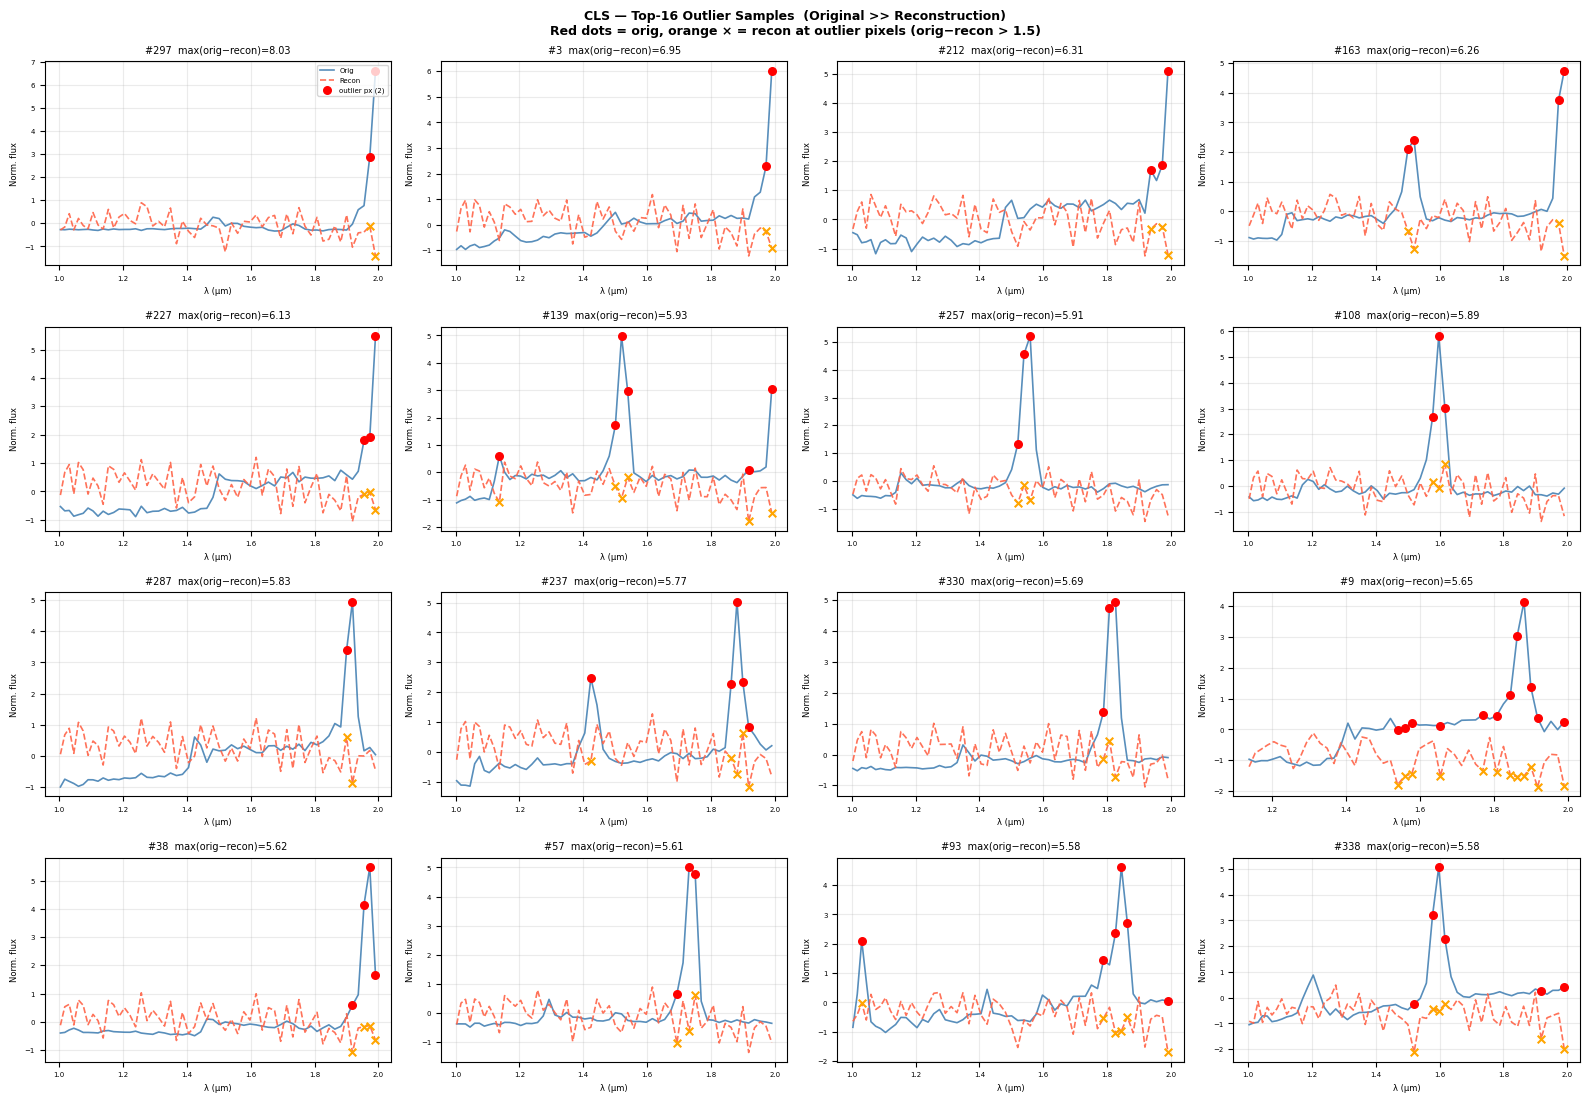

In [18]:
plot_outlier_gallery(results, recon_key='recon_cls',
                     n_outliers=N_OUTLIERS, pixel_flag_thr=PIXEL_FLAG_THR)